- BLOK A — cechy naprawdę istotne (liniowe)         [X1, X2, X3]
- BLOK B — cechy istotne nieliniowo                  [X4, X5]
- BLOK C — cechy istotne przez interakcję           [X6, X7]
- BLOK D — cechy skorelowane z istotnymi            [X8–X12]
- BLOK E — cechy o niskiej wariancji (prawie stałe) [X13, X14]
- BLOK F — czysty szum                    [X15–X25]
- BLOK G — cechy dyskretne / kategoryczne           [X26–X30]

- BLOK A
    - X1 ~ N(0,1)
    - X2 ~ N(0,1)
    - X3 ~ Exp(λ=1)
- BLOK B
    - X4 ~ N(0,1)
    - X5 ~ U(-3, 3)
- BLOK C
    - X6 ~ N(0,1)
    - X7 ~ N(0,1)
- BLOK D
    - X8 = $0.95 \cdot X_1 + \sqrt{1 - 0.95^2} \cdot \mathcal{N}(0, 1)$ - silna korelacja z X1
    - X9 = $0.80 \cdot X_1 + \sqrt{1 - 0.80^2} \cdot \mathcal{N}(0, 1)$ - trochę słabsza korelacja z X1
    - X10 = $0.90 \cdot X_4 + \sqrt{1 - 0.90^2} \cdot \mathcal{N}(0, 1)$ - korelacja ze zmienna istotną nieliniowo
    - X11 = $0.80 \cdot X_6 + \sqrt{1 - 0.80^2} \cdot \mathcal{N}(0, 1)$ - korelacja z połową interakcji
    - X12 = $0.50 \cdot X_3 + 0.50 \cdot X_1 + \sqrt{1 - 0.5^2 - 0.5^2} \cdot \mathcal{N}(0, 1)$ - kobminacja liniowa dwóch zmiennych 
- BLOK E
    - X13 ~ N(0,0.01) - istotna o niskiej wariancji
    - X14 ~ N(0.0.005) - nieistotna
- BLOK F
    - $X_{15} \dots X_{20} \sim \mathcal{N}(0, 1)$ - szum gausowski
    - X21-X23 ~ U(-2,2) - szum jednostajny
    - X24-X25 ~ N(0,1) - skorelowane ze sobą 
- BLOK G
    - X26 ~ Bern(0.5) - isotna
    - X27 ~ Bin(4,0.5) - istotna
    - X28 ~ Bern(0.8) - nieistotna
    - X29-X30 losowe wartosci {0,1,2,3}

$$Y^* = \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 (X_4^2) + \beta_5 \sin(X_5) + \beta_6 (X_6 \cdot X_7) + \beta_{13} X_{13} + \beta_{26} X_{26} + \beta_{27} X_{27}$$

Przykładowe wartości współczynników:
- Liniowe
    - $\beta_1 = 1.5$
    - $\beta_2 = 1.2$
    - $\beta_3 = 1.1$
- Nieliniowe
    - $\beta_4 = 1.3$
    - $\beta_5 = 1.5$
- Interakacja
    - $\beta_6 = 2.5$
- Niska wariancja
    - $\beta_{13} = 15$
- Kategoryczne
    - $\beta_{26} = 1.7$
    - $\beta_{27} = 1.2$

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import random

rng = np.random.default_rng(seed=111)
random.seed(111)

X1 = rng.normal(0,1,size=1000)
X2 = rng.normal(0,1,size=1000)
X3 = rng.exponential(1,size=1000)

X4 = rng.normal(0,1,size=1000)
X5 = rng.integers(-3,3,size=1000)

X6 = rng.normal(0,1,size=1000)
X7 = rng.normal(0,1,size=1000)

X8 = 0.95*X1+(1-0.95**2)**0.5 * rng.normal(0,1,size=1000)
X9 = 0.8*X1+(1-0.8**2)**0.5 * rng.normal(0,1,size=1000)
X10 = 0.9*X4+(1-0.9**2)**0.5 * rng.normal(0,1,size=1000)
X11 = 0.8*X6+(1-0.8**2)**0.5 * rng.normal(0,1,size=1000)
X12 = 0.5*X1+0.5*X3+(1-0.5**2-0.5**2)**0.5 * rng.normal(0,1,size=1000)

X13 = rng.normal(0,0.01,size=1000)
X14 = rng.normal(0,0.005,size=1000)

X15 = rng.normal(0,1,size=1000)
X16 = rng.normal(0,1,size=1000)
X17 = rng.normal(0,1,size=1000)
X18 = rng.normal(0,1,size=1000)
X19 = rng.normal(0,1,size=1000)
X20 = rng.normal(0,1,size=1000)
X21 = rng.integers(-2,2,size=1000)
X22 = rng.integers(-2,2,size=1000)
X23 = rng.integers(-2,2,size=1000)
X24 = rng.normal(0,1,size=1000)
X25 = 0.95*X24+(1-0.95**2)**0.5 * rng.normal(0,1,size=1000)

X26 = stats.bernoulli.rvs(p=0.5, size=1000)
X27 = rng.binomial(4,0.5,size=1000)
X28 = stats.bernoulli.rvs(p=0.8, size=1000)
X29 = random.choices([0, 1, 2, 3], k=1000)
X30 = random.choices([0, 1, 2, 3], k=1000)

c:\Users\wolfd\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\wolfd\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
slownik_kolumn = {
    'X1': X1,   'X2': X2,   'X3': X3,   'X4': X4,   'X5': X5,
    'X6': X6,   'X7': X7,   'X8': X8,   'X9': X9,   'X10': X10,
    'X11': X11, 'X12': X12, 'X13': X13, 'X14': X14, 'X15': X15,
    'X16': X16, 'X17': X17, 'X18': X18, 'X19': X19, 'X20': X20,
    'X21': X21, 'X22': X22, 'X23': X23, 'X24': X24, 'X25': X25,
    'X26': X26, 'X27': X27, 'X28': X28, 'X29': X29, 'X30': X30
}

df = pd.DataFrame(slownik_kolumn)

In [3]:
import math

Beta=[1.5,1.2,1.1,1.3,1.5,2.5,15,1.7,1.2]
istotne = {
    'X1': X1,   'X2': X2,   'X3': X3,   'X4': X4,   'X5': X5,
    'X6': X6,   'X7': X7,   'X13': X13, 
    'X26': X26, 'X27': X27
}

df_istotne = pd.DataFrame(istotne)
Y = Beta[0]*X1+Beta[1]*X2+Beta[2]*X3+Beta[3]*X4**2+Beta[4]*np.sin(X5)+Beta[5]*X6*X7+Beta[6]*X13+Beta[7]*X26+Beta[8]*X27

(array([  2.,   0.,   4.,   4.,  11.,  20.,  55.,  71., 111., 145., 147.,
        133., 112.,  75.,  42.,  25.,  15.,   8.,   5.,   7.,   3.,   2.,
          1.,   0.,   2.]),
 array([-9.05183979, -7.6754209 , -6.29900201, -4.92258313, -3.54616424,
        -2.16974535, -0.79332646,  0.58309243,  1.95951132,  3.33593021,
         4.7123491 ,  6.08876799,  7.46518687,  8.84160576, 10.21802465,
        11.59444354, 12.97086243, 14.34728132, 15.72370021, 17.1001191 ,
        18.47653799, 19.85295687, 21.22937576, 22.60579465, 23.98221354,
        25.35863243]),
 <BarContainer object of 25 artists>)

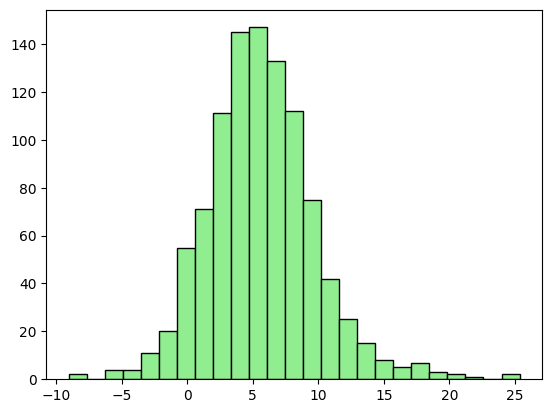

In [4]:
import matplotlib.pyplot as plt

plt.hist(Y, bins=25, color='lightgreen', edgecolor='black')

In [5]:
from scipy.special import expit

beta_0 = -np.median(Y)
Z = Y + beta_0

(array([  2.,   0.,   4.,   4.,  11.,  20.,  55.,  71., 111., 145., 147.,
        133., 112.,  75.,  42.,  25.,  15.,   8.,   5.,   7.,   3.,   2.,
          1.,   0.,   2.]),
 array([-14.43347782, -13.05705893, -11.68064004, -10.30422115,
         -8.92780227,  -7.55138338,  -6.17496449,  -4.7985456 ,
         -3.42212671,  -2.04570782,  -0.66928893,   0.70712996,
          2.08354885,   3.45996773,   4.83638662,   6.21280551,
          7.5892244 ,   8.96564329,  10.34206218,  11.71848107,
         13.09489996,  14.47131885,  15.84773773,  17.22415662,
         18.60057551,  19.9769944 ]),
 <BarContainer object of 25 artists>)

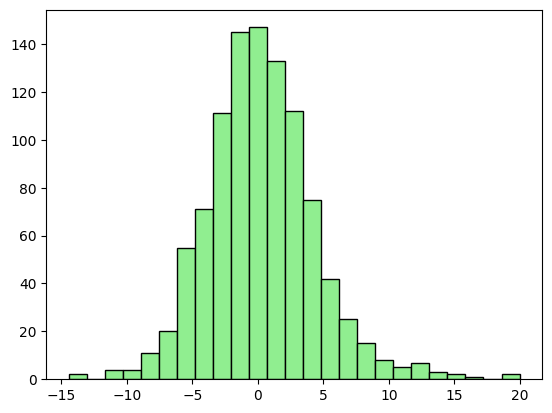

In [6]:
plt.hist(Z, bins=25, color='lightgreen', edgecolor='black')

In [7]:
pstwo = expit(Z)
Y_final = rng.binomial(n=1, p=pstwo)

In [8]:
sum(Y_final)

500

In [9]:
df['Y']=Y_final

In [10]:
df

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,X30,Y
0,-0.307438,-0.321008,1.730590,0.833916,-3,0.780486,1.568454,-0.334988,-0.961240,-0.001718,...,-2,1,1.965948,1.653540,1,3,0,3,1,1
1,-0.838657,0.378442,0.920856,1.469715,0,-0.330047,1.083323,-0.500412,-0.285231,0.854438,...,1,1,0.796119,0.521067,0,2,1,0,2,0
2,0.125638,-0.356535,0.902586,0.556410,2,-0.338767,-0.686062,-0.102820,-0.639805,0.562263,...,-2,-1,1.422506,0.731031,0,2,1,3,1,0
3,-0.660677,0.811173,0.392495,0.934048,-1,-1.128626,-0.124899,-0.449230,-0.137603,0.561763,...,1,1,-0.389034,-0.826052,0,2,1,1,1,0
4,0.158315,-0.043223,1.935064,-1.034712,-2,1.277763,-0.925314,0.290902,-1.556194,-0.930982,...,1,-1,1.704167,1.843077,0,3,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.705845,-0.192785,0.050497,1.182819,-3,-0.769177,1.303321,-1.744339,-0.644756,0.743776,...,1,-1,-1.354313,-1.595279,1,1,1,0,0,0
996,1.286893,-0.297818,0.437682,1.547938,2,-1.092817,0.927605,1.275676,-0.554750,1.578934,...,1,1,0.189722,0.353100,0,4,0,3,1,1
997,-1.117386,-0.358493,1.638156,0.973410,0,-2.239257,-0.008290,-1.106888,-0.013545,0.951992,...,-2,-2,1.434950,1.128374,1,1,1,3,1,0
998,0.086321,-0.234614,1.012391,-0.908960,-2,1.356460,2.426662,-0.186855,0.096933,-0.605418,...,0,0,-0.543628,-0.444018,0,3,1,0,2,1


In [11]:
df.to_excel('dane_syntetyczne.xlsx', index=False)